# NB 11d — Hybrid PCA + zscore-env (Kaggle PRIVATE champion)

Default config: PCA(41-46) OR zscore-env(14/21/29) → **Kaggle public 0.867 / private 0.915** —
highest *private-leaderboard* score we have. The public leaderboard is owned by **NB 11c**
(6 ch PCA, public 0.897). The FE artefact (`models/pca_fe_46ch.pkl`) comes from
**NB 11e** (wide-channel detrended PCA).

## What this does

- **Freq channels 41–46**: PCA reconstruction error (tail-fit, same as NB 11c).
- **Env channels 14/21/29**: rolling-min envelope residual → zscore (same as `ek_baseline_zscore`).
  - normalise by nominal-train std
  - normalise by p99 of |score| on train
  - grid-search k (top-k channels mean) on val
- **OR combination** with independent thresholds — a row is anomalous if either stream fires.

Set `FREQ_NAMES = []` to test env-only in isolation.

## Where this fits in the family

| Notebook | Variant                              | Kaggle pub | Kaggle priv | Role                          |
|----------|--------------------------------------|-----------:|------------:|-------------------------------|
| 11c      | 6 ch (41-46)                         |  **0.897** |       0.887 | Public-leaderboard champion   |
| **11d**  | hybrid PCA(41-46) + env-zscore       |      0.867 |   **0.915** | Private-leaderboard champion  |
| 11e      | wide-channel detrended PCA (49 / 46) |      0.868 |       0.853 | Source of the FE 46ch artefact|

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys, time, pickle
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()    # local working tree
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from sentinel.params import (
    PROCESSED_DIR, MODELS_DIR,
    RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)
from sentinel.ml_logic.scorer     import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import event_f05, corrected_event_f05, row_precision_recall
from sentinel.ml_logic.data       import find_anomaly_segments
from sentinel.ml_logic.viz        import plot_timeline, plot_event_analysis

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

KAGGLE_DIR   = PROCESSED_DIR / 'kaggle'
SUBS_DIR     = PROJECT_ROOT / 'kaggle' / 'submissions'
SUBS_DIR.mkdir(parents=True, exist_ok=True)
FIT_SIZE     = 50_000

# Envelope residual params (sweep winner: ek_11c_hybrid: env_w=200, ma_w=5000 - produced Kaggle private 0.915)
ENV_WINDOW    = 200
ENV_MA_WINDOW = 5_000
ENV_REF_PCT   = 99       # percentile for ref_per_ch normalisation

def top_p_mean(arr2d, p):
    """Mean of the top-p fraction of columns by absolute value, per row."""
    n_top = max(1, int(arr2d.shape[1] * p))
    top   = np.partition(arr2d, -n_top, axis=1)[:, -n_top:]
    return top.mean(axis=1)

print(f'KAGGLE_DIR   : {KAGGLE_DIR}')
print(f'WINDOW_SIZE  : {WINDOW_SIZE}   FIT_SIZE: {FIT_SIZE:,}')
print(f'ENV_WINDOW   : {ENV_WINDOW}    ENV_MA_WINDOW: {ENV_MA_WINDOW:,}')

KAGGLE_DIR   : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed/kaggle
WINDOW_SIZE  : 100   FIT_SIZE: 50,000
ENV_WINDOW   : 200    ENV_MA_WINDOW: 5,000


In [ ]:
# ── Freq channels: raw scaled (PCA) ───────────────────────────────────────────
FREQ_NAMES = [f'channel_{i}' for i in range(41, 47)]   # set [] for env-only
# FREQ_NAMES = []

# ── Env channels: envelope residual (zscore) ──────────────────────────────────
# NB 18 found 10 lock-step level-shift drifters (sorted by |kaggle_test_z| desc):
#   29, 14, 21, 30, 38, 22, 31, 39, 15, 23
# We tested the full 10-channel set (k-grid picked top-3 of 10): val improved
# (0.94 → 0.96) but test dropped (0.82 → 0.75) - adding candidates overfits
# the k-selection to val. The original 3-channel set is the local optimum.
ENV_NAMES  = ['channel_14', 'channel_21', 'channel_29']
# ENV_NAMES = ['channel_29','channel_14','channel_21','channel_30','channel_38',
#              'channel_22','channel_31','channel_39','channel_15','channel_23']  # full 10
# ENV_NAMES = []

_TARGET_CH = pd.read_csv(PROJECT_ROOT / 'data/raw/target_channels.csv')['target_channels'].tolist()
missing    = [c for c in FREQ_NAMES + ENV_NAMES if c not in _TARGET_CH]
assert not missing, f'Missing channels: {missing}'

FREQ_IDX   = np.array([_TARGET_CH.index(n) for n in FREQ_NAMES], dtype=int)
ENV_IDX    = np.array([_TARGET_CH.index(n) for n in ENV_NAMES],  dtype=int)
CH_NAMES   = FREQ_NAMES + ENV_NAMES
CH_INDICES = np.concatenate([FREQ_IDX, ENV_IDX])
assert len(CH_NAMES) > 0, 'At least one group must be non-empty'

print(f'FREQ channels : {FREQ_NAMES or "(none)"}')
print(f'ENV  channels : {ENV_NAMES  or "(none)"}')

FREQ channels : ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
ENV  channels : ['channel_14', 'channel_21', 'channel_29']


In [30]:
DATA_SOURCE = 'kaggle'

y_train_full      = np.load(KAGGLE_DIR / 'y_train_full.npy')
train_scaled_full = np.load(KAGGLE_DIR / 'train_full_scaled.npy', mmap_mode='r')
test_scaled_full  = np.load(KAGGLE_DIR / 'test_scaled.npy')
test_ids          = np.load(KAGGLE_DIR / 'test_ids.npy')
y_train_row       = np.load(KAGGLE_DIR / 'y_train_row.npy')

TRAIN_END, VAL_END = 10_700_000, 12_700_000
nominal_mask       = (y_train_full == 0)

# ── Freq channels: raw RobustScaler-normalised ────────────────────────────────
train_freq = np.ascontiguousarray(train_scaled_full[:, FREQ_IDX], dtype=np.float32)
test_freq  = test_scaled_full[:, FREQ_IDX].astype(np.float32)

# ── Env channels: envr = rolling_min(200) − centred_MA(5000) ─────────────────
def _envr_cols(arr2d, env_w, ma_w):
    out = np.empty_like(arr2d, dtype=np.float32)
    for j in range(arr2d.shape[1]):
        s   = pd.Series(arr2d[:, j])
        env = s.rolling(window=env_w, min_periods=1).min()
        ma  = env.rolling(window=ma_w, min_periods=1, center=True).mean()
        out[:, j] = (env - ma).values.astype(np.float32)
    return out

if len(ENV_IDX):
    print('Computing env residuals for train …')
    t0 = time.time()
    train_envr = _envr_cols(
        np.ascontiguousarray(train_scaled_full[:, ENV_IDX], dtype=np.float32),
        ENV_WINDOW, ENV_MA_WINDOW)
    print(f'  done in {time.time()-t0:.1f}s')

    print('Computing env residuals for test …')
    test_envr = _envr_cols(test_scaled_full[:, ENV_IDX].astype(np.float32),
                           ENV_WINDOW, ENV_MA_WINDOW)

    # Step 1: normalise by nominal-train std (same as ek_11c)
    _nom_mask_row = y_train_row[:TRAIN_END] == 0
    _envr_std = np.maximum(
        train_envr[:TRAIN_END][_nom_mask_row].std(axis=0, keepdims=True), 1e-6)
    train_envr = (train_envr / _envr_std).astype(np.float32)
    test_envr  = (test_envr  / _envr_std).astype(np.float32)

    # Step 2: ref_per_ch = p99 of |z_raw| on training period (same as ek_baseline_zscore)
    ref_per_ch_env = np.maximum(
        np.percentile(np.abs(train_envr[:TRAIN_END]), ENV_REF_PCT, axis=0), 1e-8
    ).astype(np.float32)
    print(f'ref_per_ch_env (p{ENV_REF_PCT}): {ref_per_ch_env.round(3).tolist()}')
else:
    train_envr = np.empty((train_scaled_full.shape[0], 0), dtype=np.float32)
    test_envr  = np.empty((test_scaled_full.shape[0],  0), dtype=np.float32)
    ref_per_ch_env = np.empty(0, dtype=np.float32)

# ── Stack freq + envr ─────────────────────────────────────────────────────────
train_scaled = np.concatenate([train_freq, train_envr], axis=1)
test_scaled  = np.concatenate([test_freq,  test_envr],  axis=1)
del train_freq, train_envr, test_freq, test_envr

X_val  = np.ascontiguousarray(train_scaled[TRAIN_END:VAL_END], dtype=np.float32)
y_val  = y_train_row[TRAIN_END:VAL_END]
X_test = np.ascontiguousarray(train_scaled[VAL_END:],          dtype=np.float32)
y_test = y_train_row[VAL_END:]

print(f'train_scaled : {train_scaled.shape}')
print(f'X_val        : {X_val.shape}   anom rows: {int(y_val.sum()):>8,}')
print(f'X_test       : {X_test.shape}   anom rows: {int(y_test.sum()):>8,}')

Computing env residuals for train …
  done in 1.1s
Computing env residuals for test …
ref_per_ch_env (p99): [6.769000053405762, 7.142000198364258, 5.263999938964844]
train_scaled : (14728321, 9)
X_val        : (2000000, 9)   anom rows:  215,798
X_test       : (2028321, 9)   anom rows:  214,935


In [ ]:
n_freq = len(FREQ_IDX)
n_env  = len(ENV_IDX)

# Shared tail-fit window indices
win_end_row = (np.arange(len(y_train_full)) + 1) * WINDOW_SIZE
eligible    = nominal_mask & (win_end_row <= TRAIN_END)
fit_idx     = np.flatnonzero(eligible)[-FIT_SIZE:]
_row_idx    = (fit_idx[:, None] * WINDOW_SIZE + np.arange(WINDOW_SIZE)[None, :]).ravel()

# ── Freq PCA only (env uses zscore - no PCA needed) ──────────────────────────
if n_freq:
    X_fit_freq = train_scaled[_row_idx, :n_freq].reshape(len(fit_idx), -1).astype(np.float32)
    t0 = time.time()
    pca_freq = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_fit_freq)
    print(f'FREQ PCA  k={pca_freq.n_components_}  '
          f'EV={pca_freq.explained_variance_ratio_.sum():.4f}  '
          f'({X_fit_freq.shape[1]:,} features, {time.time()-t0:.1f}s)')
    del X_fit_freq
else:
    pca_freq = None
    print('FREQ channels disabled - pca_freq = None')

del _row_idx

FREQ PCA  k=183  EV=0.9502  (600 features, 0.5s)


In [ ]:
t0 = time.time()

# ── Freq: PCA reconstruction error (row-level) ────────────────────────────────
val_scores_freq  = (score_windows(pca_freq, X_val[:, :n_freq])
                    if pca_freq is not None
                    else np.zeros(len(y_val), dtype=np.float32))
test_scores_freq = (score_windows(pca_freq, X_test[:, :n_freq])
                    if pca_freq is not None
                    else np.zeros(len(y_test), dtype=np.float32))

# ── Env: per-channel absolute zscore (envr / std / ref_per_ch) ────────────────
# Shape: (n_rows, n_env) - absolute values so spikes in both directions are caught
if n_env:
    z_val_env  = np.abs(X_val[:,  n_freq:] / ref_per_ch_env).astype(np.float32)
    z_test_env = np.abs(X_test[:, n_freq:] / ref_per_ch_env).astype(np.float32)
else:
    z_val_env  = np.empty((len(y_val),  0), dtype=np.float32)
    z_test_env = np.empty((len(y_test), 0), dtype=np.float32)

print(f'scoring done in {time.time()-t0:.1f}s')
print(f'val freq : [{val_scores_freq.min():.4f}, {val_scores_freq.max():.4f}]  mean={val_scores_freq.mean():.4f}')
if n_env:
    print(f'val env  : per-ch max={z_val_env.max(axis=0).round(2).tolist()}')

scoring done in 0.3s
val freq : [0.0114, 30.4105]  mean=0.0233
val env  : per-ch max=[8.300000190734863, 4.329999923706055, 7.539999961853027]


In [33]:
# ── Freq: standard threshold tuning ──────────────────────────────────────────
if pca_freq is not None:
    tuned_freq     = tune_threshold(val_scores_freq, y_val, corrected_event_f05, n_sweep=80)
    threshold_freq = float(tuned_freq['threshold'])
    print(f'FREQ  thr={threshold_freq:.6f}   val F0.5={tuned_freq["score"]:.4f}')
else:
    threshold_freq = np.inf

# ── Env: grid search over k (1..n_env) then tune threshold ───────────────────
if n_env:
    print(f'\n── ENV k-grid search ({n_env} channels) ──────────────────')
    print(f'  {"k":>3}  {"val F0.5":>9}  {"thr":>10}')
    best_env_f05, best_p_env, best_thr_env = -1.0, 1.0, None
    for k in range(1, n_env + 1):
        p   = k / n_env
        sc  = top_p_mean(z_val_env, p=p)
        res = tune_threshold(sc, y_val, corrected_event_f05, n_sweep=80)
        print(f'  {k:>3}  {res["score"]:>9.4f}  {res["threshold"]:>10.4f}')
        if res['score'] > best_env_f05:
            best_env_f05 = res['score']
            best_p_env   = p
            best_thr_env = res['threshold']
    threshold_env = float(best_thr_env)
    k_env = int(round(best_p_env * n_env))
    print(f'\n→ best k={k_env}/{n_env}  thr={threshold_env:.6f}  val F0.5={best_env_f05:.4f}')

    val_scores_env  = top_p_mean(z_val_env,  p=best_p_env)
    test_scores_env = top_p_mean(z_test_env, p=best_p_env)
else:
    threshold_env   = np.inf
    best_p_env      = 1.0
    val_scores_env  = np.zeros(len(y_val),  dtype=np.float32)
    test_scores_env = np.zeros(len(y_test), dtype=np.float32)

# ── OR-combined preview ───────────────────────────────────────────────────────
_y_or = ((val_scores_freq > threshold_freq) |
         (val_scores_env  > threshold_env )).astype(np.int8)
print(f'\nOR combined  val corrected_event_f05: '
      f'{corrected_event_f05(y_val, _y_or)["f_score"]:.4f}')

# Unified score for viz (max of normalised, threshold = 1.0)
def _combined(sf, se):
    sf_n = sf / threshold_freq if threshold_freq < np.inf else np.zeros_like(sf)
    se_n = se / threshold_env  if threshold_env  < np.inf else np.zeros_like(se)
    return np.maximum(sf_n, se_n)

val_scores  = _combined(val_scores_freq, val_scores_env)
test_scores = _combined(test_scores_freq, test_scores_env)
threshold   = 1.0

FREQ  thr=0.028049   val F0.5=0.8534

── ENV k-grid search (3 channels) ──────────────────
    k   val F0.5         thr
    1     0.7816      0.9315
    2     0.7829      1.2370
    3     0.7827      1.0782

→ best k=2/3  thr=1.236990  val F0.5=0.7829

OR combined  val corrected_event_f05: 0.9391


In [34]:
# Joint-threshold step disabled to match Ekaterina's 0.915-private config
# (independent thresholds only). Re-enable only after submission verifies
# the regression hypothesis (ma_w=20000 + joint adoption hurt private).
print('joint-threshold step skipped (matching ek_11c_hybrid config)')


joint-threshold step skipped (matching ek_11c_hybrid config)


In [35]:
def compute_metrics(scores, y_true, threshold):
    y_pred = (scores > threshold).astype(np.int8)
    ef     = event_f05(y_true, y_pred)
    esa    = corrected_event_f05(y_true, y_pred)
    rw     = row_precision_recall(y_true, y_pred)
    n_ev_total = int(ef['tp_events'] + ef['fn_events'])
    n_ev_hit   = int(ef['tp_events'])
    return {
        'ESA F0.5 (Kaggle)' : esa['f_score'],
        'Pr_ew (event prec)': esa['precision'],
        'TNR (row spec)'    : esa['tnr'],
        'event F0.5 (raw)'  : ef['f_score'],
        'event recall'      : ef['recall'],
        'event precision'   : ef['precision'],
        'row precision'     : rw['precision'],
        'row recall'        : rw['recall'],
        'row F1'            : rw['f1'],
        'flag rate'         : float(y_pred.mean()),
        'events hit'        : f'{n_ev_hit}/{n_ev_total} ({n_ev_hit/max(n_ev_total,1):.1%})',
        '_y_pred'           : y_pred,
    }

m_val  = compute_metrics(val_scores,  y_val,  threshold)
m_test = compute_metrics(test_scores, y_test, threshold)

metrics_order = ['ESA F0.5 (Kaggle)', 'Pr_ew (event prec)', 'TNR (row spec)',
                 'event F0.5 (raw)', 'event recall', 'event precision',
                 'row precision', 'row recall', 'row F1', 'flag rate', 'events hit']

def _fmt(v):
    if isinstance(v, str):   return v
    if isinstance(v, float): return f'{v:.4f}' if abs(v) >= 1e-4 else f'{v:.2e}'
    return str(v)

df_m = pd.DataFrame({'Metric': metrics_order,
                     'Val'   : [m_val[k]  for k in metrics_order],
                     'Test'  : [m_test[k] for k in metrics_order]})
df_m['Val']  = df_m['Val'].map(_fmt)
df_m['Test'] = df_m['Test'].map(_fmt)

freq_lbl = ','.join(c.replace('channel_','') for c in FREQ_NAMES) or 'none'
env_lbl  = ','.join(c.replace('channel_','') for c in ENV_NAMES)  or 'none'
print(f'freq=[{freq_lbl}]  env=[{env_lbl}]  '
      f'k_env={k_env if n_env else 0}/{n_env}  '
      f'thr_freq={threshold_freq:.4f}  thr_env={threshold_env:.4f}')
print(df_m.to_string(index=False))

freq=[41,42,43,44,45,46]  env=[14,21,29]  k_env=2/3  thr_freq=0.0280  thr_env=1.2370
            Metric           Val          Test
 ESA F0.5 (Kaggle)        0.9391        0.8216
Pr_ew (event prec)        0.9939        0.9303
    TNR (row spec)        0.9939        0.9967
  event F0.5 (raw)        0.9434        0.8235
      event recall        0.7692        0.5600
   event precision        1.0000        0.9333
     row precision        0.5386        0.7711
        row recall        0.0587        0.0937
            row F1        0.1059        0.1672
         flag rate        0.0118        0.0129
        events hit 20/26 (76.9%) 14/25 (56.0%)


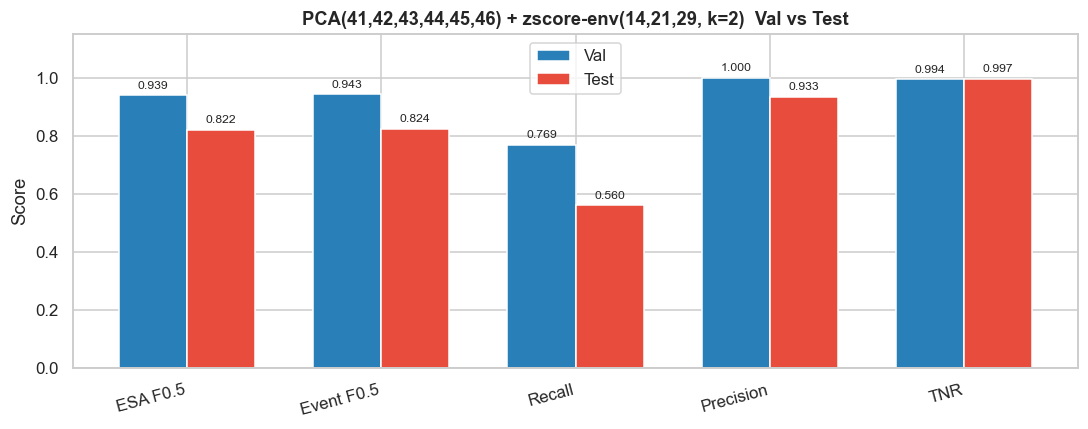

In [36]:
LABEL_TO_KEY = {
    'ESA F0.5'  : 'ESA F0.5 (Kaggle)',
    'Event F0.5': 'event F0.5 (raw)',
    'Recall'    : 'event recall',
    'Precision' : 'event precision',
    'TNR'       : 'TNR (row spec)',
}
labels = list(LABEL_TO_KEY)
x = np.arange(len(labels)); w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
b1 = ax.bar(x - w/2, [m_val[LABEL_TO_KEY[l]]  for l in labels], w, label='Val',  color=NOMINAL_COLOR)
b2 = ax.bar(x + w/2, [m_test[LABEL_TO_KEY[l]] for l in labels], w, label='Test', color=ANOMALY_COLOR)
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=3)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score'); ax.legend()
ax.set_title(f'PCA({freq_lbl}) + zscore-env({env_lbl}, k={k_env if n_env else 0})  Val vs Test',
             fontweight='bold')
fig.tight_layout(); plt.show()

## Score distribution + per-stream contribution

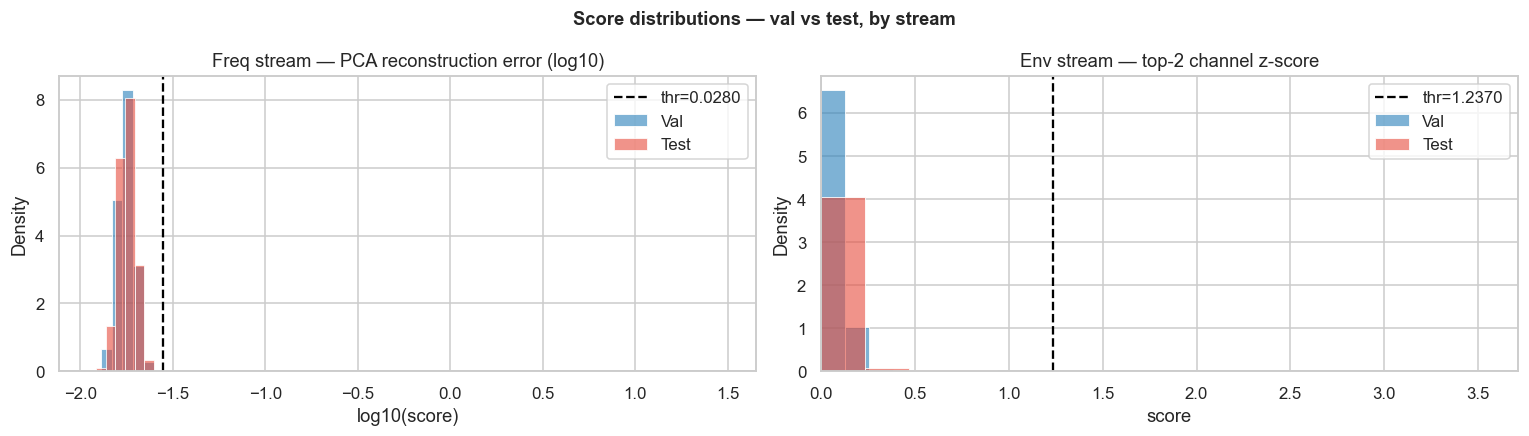

In [ ]:
# Score histograms - freq vs env, val vs test, with thresholds drawn
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Freq stream ────────────────────────────────────────────────────────────
sns.histplot(np.log10(np.maximum(val_scores_freq,  1e-6)), bins=60,
             ax=axes[0], label='Val',  color=NOMINAL_COLOR, alpha=0.6, stat='density')
sns.histplot(np.log10(np.maximum(test_scores_freq, 1e-6)), bins=60,
             ax=axes[0], label='Test', color=ANOMALY_COLOR, alpha=0.6, stat='density')
axes[0].axvline(np.log10(threshold_freq), color='black', ls='--', label=f'thr={threshold_freq:.4f}')
axes[0].set_title(f'Freq stream - PCA reconstruction error (log10)')
axes[0].set_xlabel('log10(score)'); axes[0].legend()

# ── Env stream ─────────────────────────────────────────────────────────────
if n_env:
    sns.histplot(val_scores_env,  bins=60, ax=axes[1], label='Val',
                 color=NOMINAL_COLOR, alpha=0.6, stat='density')
    sns.histplot(test_scores_env, bins=60, ax=axes[1], label='Test',
                 color=ANOMALY_COLOR, alpha=0.6, stat='density')
    axes[1].axvline(threshold_env, color='black', ls='--', label=f'thr={threshold_env:.4f}')
    axes[1].set_title(f'Env stream - top-{k_env} channel z-score')
    axes[1].set_xlabel('score'); axes[1].legend()
    axes[1].set_xlim(0, max(threshold_env * 3, val_scores_env.max() * 0.3))

fig.suptitle('Score distributions - val vs test, by stream', fontweight='bold')
fig.tight_layout(); plt.show()

## Stream-attribution - which events caught by freq vs env vs both

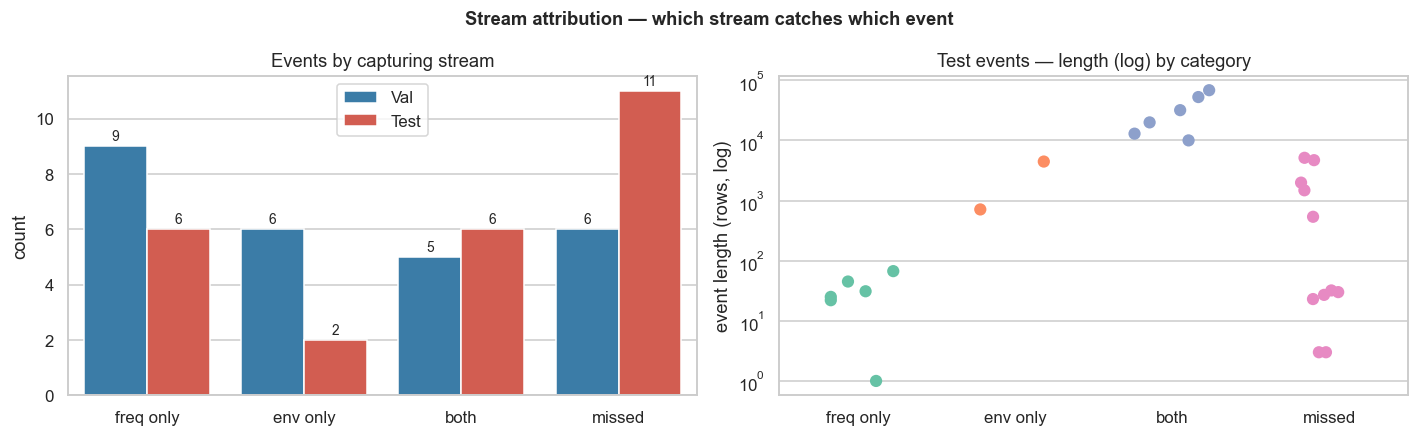

In [ ]:
# For each event in val and test, classify which stream caught it (freq / env / both / missed)
def stream_attribution(scores_freq, scores_env, y_true, thr_f, thr_e):
    flag_f = scores_freq > thr_f
    flag_e = scores_env  > thr_e
    rows = []
    for ev in find_anomaly_segments(y_true):
        s, e = ev['start'], ev['end'] + 1
        f_hit = bool(flag_f[s:e].any())
        e_hit = bool(flag_e[s:e].any())
        if f_hit and e_hit:   cat = 'both'
        elif f_hit:           cat = 'freq only'
        elif e_hit:           cat = 'env only'
        else:                 cat = 'missed'
        rows.append({'length': ev['end'] - ev['start'] + 1, 'category': cat})
    return pd.DataFrame(rows)

attr_val  = stream_attribution(val_scores_freq,  val_scores_env,  y_val,  threshold_freq, threshold_env)
attr_test = stream_attribution(test_scores_freq, test_scores_env, y_test, threshold_freq, threshold_env)

# Stacked bar - counts per category, val vs test
order = ['freq only', 'env only', 'both', 'missed']
val_counts  = attr_val['category'].value_counts().reindex(order, fill_value=0)
test_counts = attr_test['category'].value_counts().reindex(order, fill_value=0)
df_attr = pd.DataFrame({'Val': val_counts, 'Test': test_counts}).reset_index().rename(columns={'index':'category'})
df_long = df_attr.melt(id_vars='category', var_name='split', value_name='count')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=df_long, x='category', y='count', hue='split', ax=axes[0],
            palette=[NOMINAL_COLOR, ANOMALY_COLOR], order=order)
for c in axes[0].containers:
    axes[0].bar_label(c, fontsize=9, padding=2)
axes[0].set_title('Events by capturing stream'); axes[0].set_xlabel(''); axes[0].legend(title='')

# Scatter: event length vs category (test only - what's missed and how big)
attr_test_l = attr_test.copy()
attr_test_l['log_len'] = np.log10(attr_test_l['length'])
sns.stripplot(data=attr_test_l, x='category', y='length', ax=axes[1],
              order=order, size=8, jitter=0.25, palette='Set2')
axes[1].set_yscale('log'); axes[1].set_title('Test events - length (log) by category')
axes[1].set_xlabel(''); axes[1].set_ylabel('event length (rows, log)')

fig.suptitle('Stream attribution - which stream catches which event', fontweight='bold')
fig.tight_layout(); plt.show()

## Timeline - score curves with predicted vs true bands

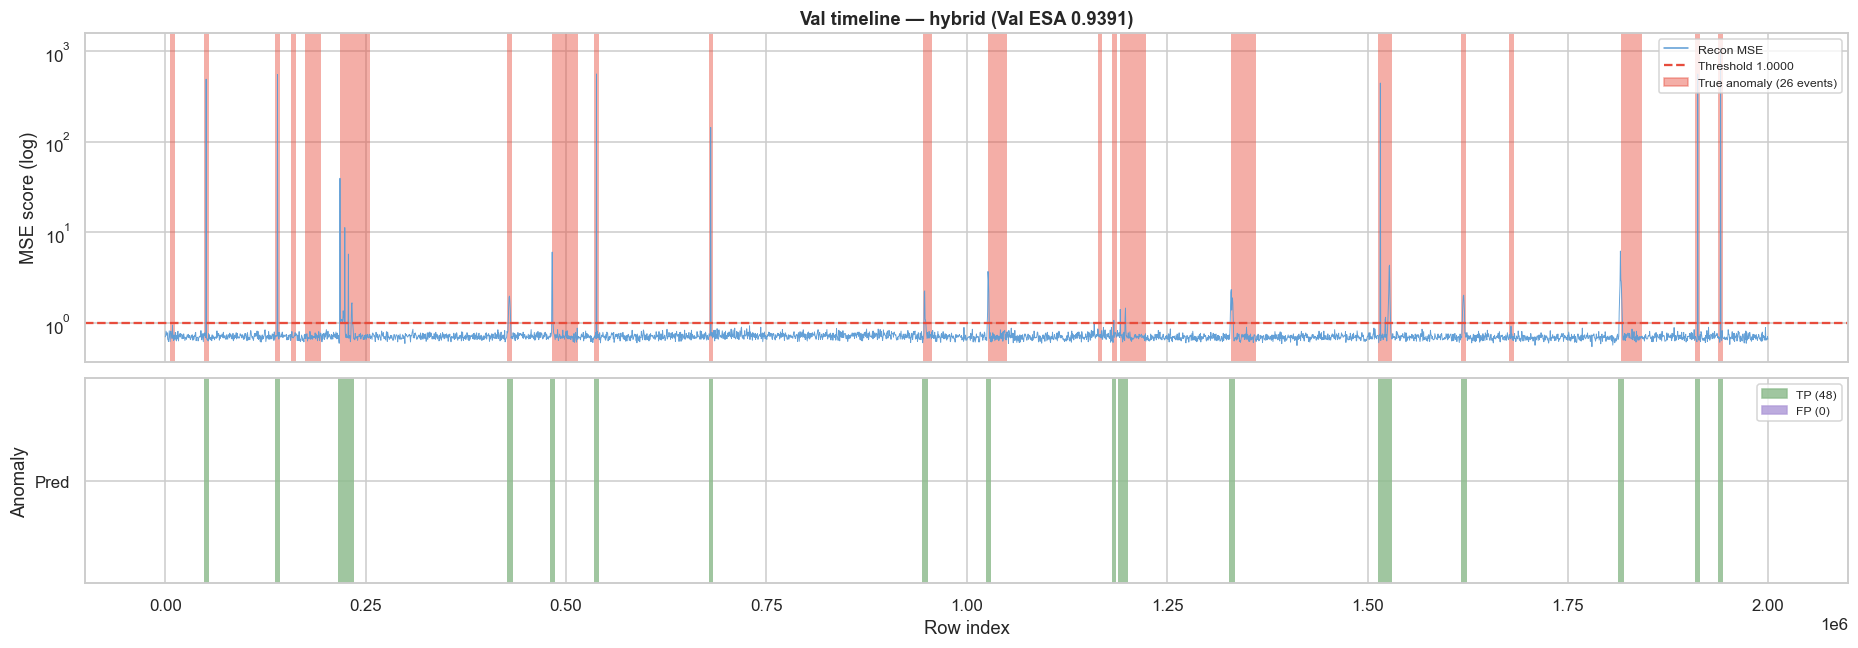

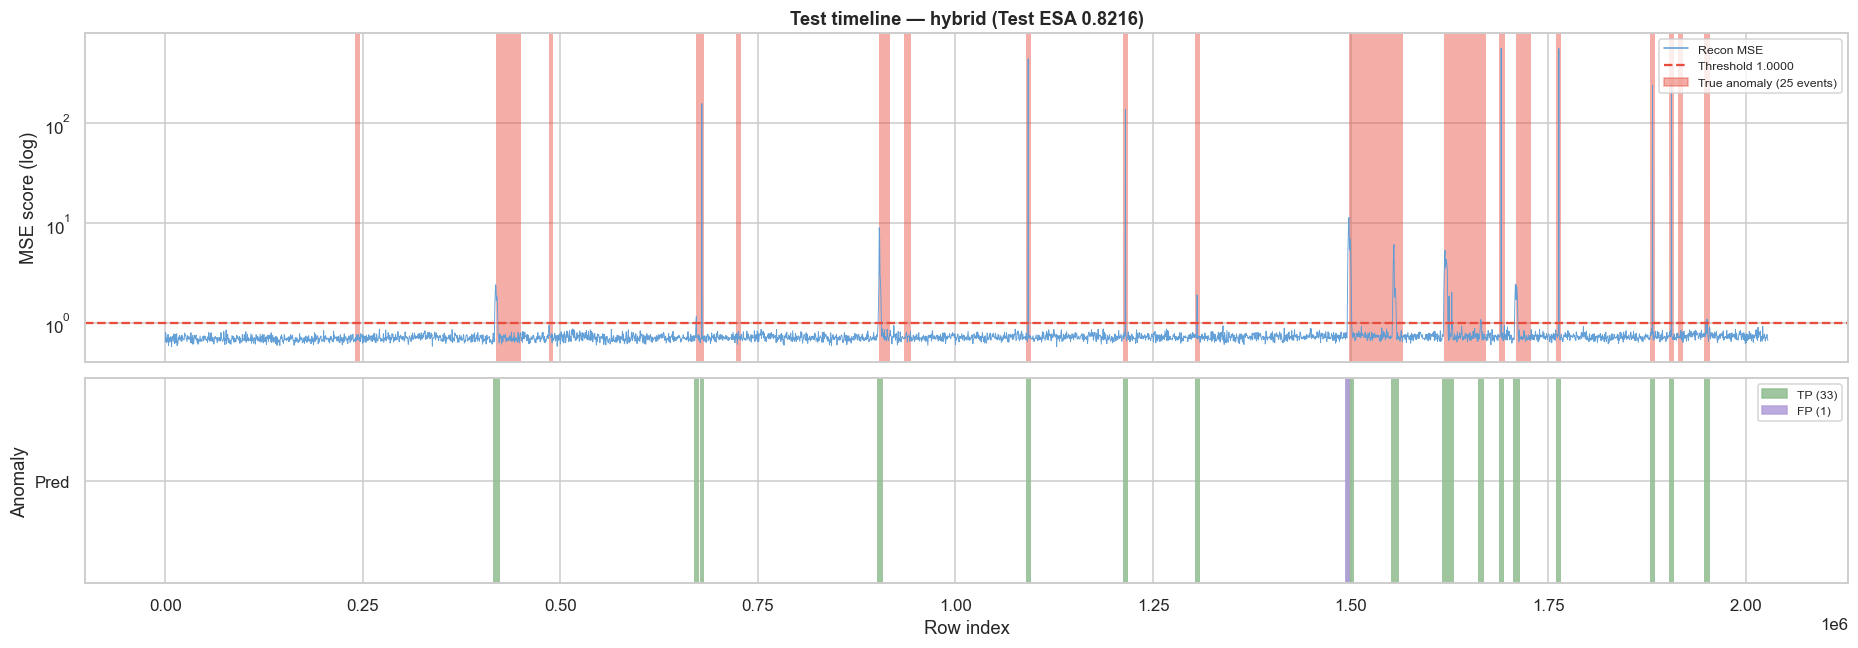

In [ ]:
# Timeline: combined-score curves (val and test) with predicted vs true anomaly bands
_ = plot_timeline(val_scores,  y_val,  threshold,
                  title=f'Val timeline - hybrid (Val ESA {m_val["ESA F0.5 (Kaggle)"]:.4f})',
                  log_y=True)
_ = plot_timeline(test_scores, y_test, threshold,
                  title=f'Test timeline - hybrid (Test ESA {m_test["ESA F0.5 (Kaggle)"]:.4f})',
                  log_y=True)


## Event analysis - per-event detection vs miss


Missed events:
  start     end  length
   9219    9587     369
 158321  162679    4359
 174923  193837   18915
 952299  954134    1836
1165985 1166260     276
1679098 1680347    1250
Missed events:
  start     end  length
 242499  243978    1480
 485619  490754    5136
 722632  727323    4692
 937585  937616      32
 938221  938247      27
 939737  939759      23
 940375  940404      30
1690836 1692821    1986
1916825 1917361     537
1949666 1949668       3
1949681 1949683       3


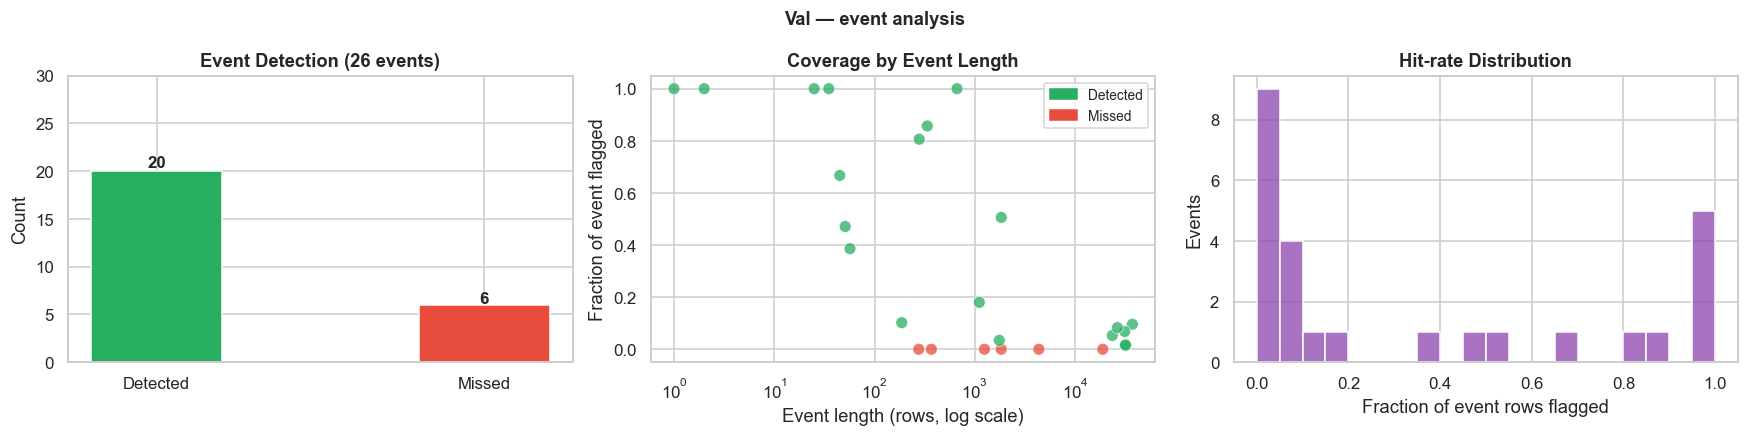

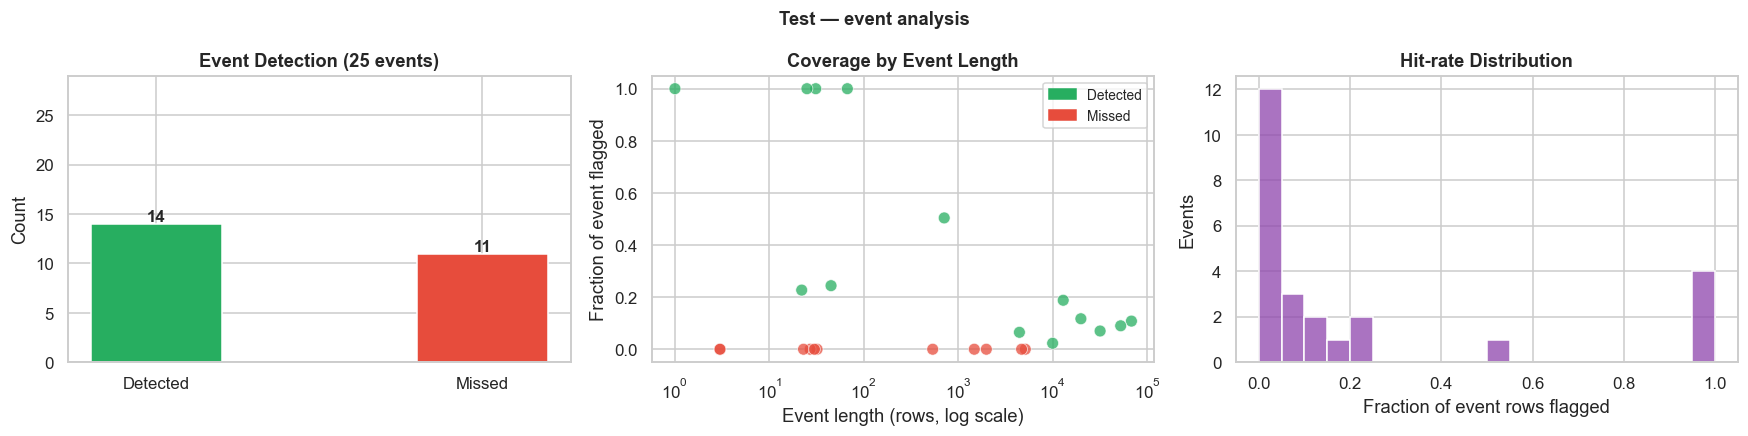

In [ ]:
_ = plot_event_analysis(y_val,  m_val['_y_pred'],  title='Val - event analysis')
_ = plot_event_analysis(y_test, m_test['_y_pred'], title='Test - event analysis')


In [ ]:
# ── Kaggle submission ──────────────────────────────────────────────────────
# X_kaggle = test_scaled.astype(np.float32, copy=False)

# kf = (score_windows(pca_freq, X_kaggle[:, :n_freq])
#       if pca_freq is not None else np.zeros(len(X_kaggle), dtype=np.float32))

# if n_env:
#     z_ke   = np.abs(X_kaggle[:, n_freq:] / ref_per_ch_env).astype(np.float32)
#     ke     = top_p_mean(z_ke, p=best_p_env)
# else:
#     ke     = np.zeros(len(X_kaggle), dtype=np.float32)

# y_kaggle = ((kf > threshold_freq) | (ke > threshold_env)).astype(np.uint8)
# print(f'positive rate : {y_kaggle.mean():.4%}  ({int(y_kaggle.sum()):,} / {len(y_kaggle):,})')

# submission = pd.DataFrame({'id': test_ids, 'is_anomaly': y_kaggle})
# sample_sub = pd.read_parquet(PROJECT_ROOT / 'data/raw/sample_submission.parquet')
# assert list(submission['id']) == list(sample_sub['id']), 'ID mismatch'

# ts   = time.strftime('%Y%m%d_%H%M%S')
# out  = SUBS_DIR / f'pca_hybrid_envzscore_{ts}.parquet'
# submission.to_parquet(out, index=False)
# print(f'Saved \u2192 {out}')


positive rate : 1.5226%  (7,937 / 521,280)
Saved → /Users/helena.schulz.ext/code/alexfederolf/sentinel/kaggle/submissions/pca_zsenv_20260429_111511.parquet
